# Lab 01: Urbana Weather

---
author: Trishla Nair
date: September 6, 2024
embed-resources: true
---

## Introduction

## Methods

In [56]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error
from joblib import dump

### Data

In [57]:
# load data
weather_train = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-train.csv",
    index_col="date",
    parse_dates=True
)
weather_vtrain = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-vtrain.csv",
    index_col="date",
    parse_dates=True
)
weather_validation = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-validation.csv",
    index_col="date",
    parse_dates=True
)
weather_test = pd.read_csv(
    "https://cs307.org/lab-01/data/weather-test.csv",
    index_col="date",
    parse_dates=True
)

In [58]:
weather_train

,temperature_2m_min,year,month,day,day_of_year
date,,,,,
2016-01-01,-4.2715,2016,1,1,1
2016-01-02,-3.8715,2016,1,2,2
2016-01-03,-4.4715,2016,1,3,3
2016-01-04,-3.0215,2016,1,4,4
2016-01-05,-5.7715,2016,1,5,5
...,...,...,...,...,...
2021-12-27,6.9980,2021,12,27,361
2021-12-28,1.7980,2021,12,28,362
2021-12-29,2.1980,2021,12,29,363


In [59]:
# summary statistics
year = weather_train.groupby(["year"]).agg(['count', 'mean', 'std'])
year = year['temperature_2m_min'].reset_index()
year

,year,count,mean,std
0,2016,366,8.793391,10.274506
1,2017,365,8.399644,9.692305
2,2018,365,7.591014,11.369452
3,2019,365,7.229781,10.882260
4,2020,366,7.684612,9.383593
5,2021,365,8.119370,10.388489


In [60]:
month = weather_train.groupby(["month"]).agg(['mean', 'std'])
month = month['temperature_2m_min'].reset_index()
month

,month,mean,std
0,1,-4.999336,6.752006
1,2,-3.856209,6.760570
2,3,1.577277,5.615212
3,4,5.985861,5.615279
4,5,12.446632,5.342291
5,6,18.240583,3.492687
6,7,19.975933,2.632969
7,8,19.136954,2.889118
8,9,16.793083,3.815779
9,10,10.102277,5.852142


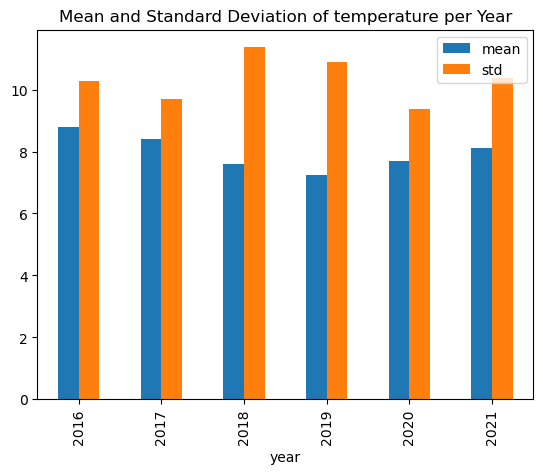

In [61]:
# visualizations

year = pd.DataFrame(year)
year.plot(x = "year", y = ['mean', 'std'], kind = "bar")
plt.title("Mean and Standard Deviation of temperature per Year")
plt.show()

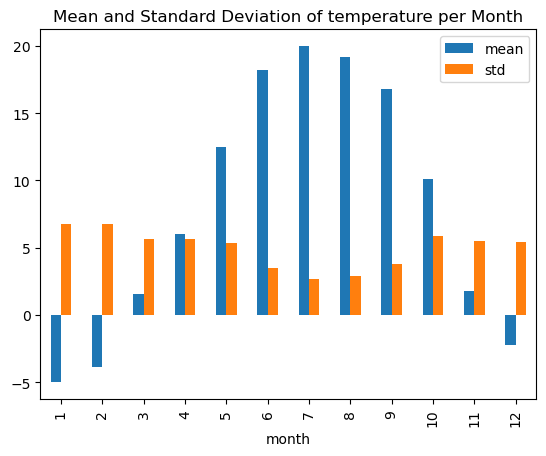

In [62]:
month = pd.DataFrame(month)
month.plot(x = "month", y = ['mean', 'std'], kind = "bar")
plt.title("Mean and Standard Deviation of temperature per Month")
plt.show()

### Models

In [63]:
# process data for ML
# create X and y for train
X_train = weather_train[["year", "day_of_year"]]
Y_train = weather_train["temperature_2m_min"]

# create X and y for validation-train
X_vtrain = weather_vtrain[["year", "day_of_year"]]
Y_vtrain = weather_vtrain["temperature_2m_min"]

# create X and y for validation
X_validation = weather_validation[["year", "day_of_year"]]
Y_validation = weather_validation["temperature_2m_min"]

In [64]:
# create X and y for test
X_test = weather_test[["year", "day_of_year"]]
Y_test = weather_test["temperature_2m_min"]

In [65]:
# train models
knn_list = []
for i in range (1,365):
    knn = KNeighborsRegressor(n_neighbors = i)
    knn.fit(X_vtrain,Y_vtrain)
    predict = knn.predict(X_validation)
    knn_list.append(root_mean_squared_error(Y_validation, predict))
knn_series = pd.Series(knn_list)
knn_series

0      6.536355
1      6.052572
2      5.882233
3      5.563822
4      5.493198
         ...   
359    4.748678
360    4.749222
361    4.755639
362    4.759474
363    4.766864
Length: 364, dtype: float64

In [66]:
mod = KNeighborsRegressor(n_neighbors = 230)
mod.fit(X_vtrain,Y_vtrain)
predict = knn.predict(X_validation)

## Results

In [67]:
# report model metrics
print("index: ",knn_series.idxmin(), "\n","RMSE value: ",knn_series.min())

index:  230 
 RMSE value:  4.573227448120473


In [68]:
mod_t = KNeighborsRegressor(n_neighbors = 230)
_ = mod_t.fit(X_test,Y_test)
predict = mod_t.predict(X_test)
print(root_mean_squared_error(Y_test, predict))

10.237848839853822


In [70]:
knn = KNeighborsRegressor(n_neighbors = 230)
knn.fit(X_vtrain,Y_vtrain)
predict = knn.predict(X_validation)
dump(knn, "urbana-weather.joblib")

['urbana-weather.joblib']

When applying the KNN regressor model, the smallest calculated Root Mean Squared Error is at 230 neighbors, with an RMSE value of 4.573227448120473

## Discussion

Based off the results of the KNN Regression model, the RMSE value is a good fit for trying to estimate temperature based on the day. A 4 degree difference in temperature isn't really noticible or felt by humans. But the model's limitation is that it does not factor in the month or season. There is only a specific window of time that is overall optimal.

### Conclusion

The model is a good fit for the data and the scenario the data is being applied to.